<a href="https://colab.research.google.com/github/Arnav111garg/Basic_Quant-ML_projects/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***LOGISTIC REGRESSION***

**Logistic regression is a supervised machine learning algorithm used for classification problems to predict the probability that an input belongs to a specific class, rather than predicting continuous values like linear regression.  It is primarily used for binary classification tasks where the output is categorical (e.g., 0 or 1, Yes or No, Spam or Not Spam), though it can be extended to multinomial cases with multiple unordered categories.**


## ***ASSUMPTIONS OF LOGISTIC REGRESSION***

- **Independent observations**:

  Each data point is assumed to be independent of the others means there should be no correlation or dependence between the input samples.

- **Binary dependent variables**:
  
  It takes the assumption that the dependent variable must be binary, means it can take only two values. For more than two categories SoftMax functions are used.

- **Linearity relationship between independent variables and log odds**:

  The model assumes a linear relationship between the independent variables and the log odds of the dependent variable which means the predictors affect the log odds in a linear way.

- **No outliers**:

  The dataset should not contain extreme outliers as they can distort the estimation of the logistic regression coefficients.

- **Large sample size**:

  It requires a sufficiently large sample size to produce reliable and stable results.

## ***UNDERSTANDING SIGMOID FUNCTON***

1. The sigmoid function is a important part of logistic regression which is used to convert the raw output of the model into a probability value between 0 and 1.

2. This function takes any real number and maps it into the range 0 to 1 forming an "S" shaped curve called the sigmoid curve or logistic curve. Because probabilities must lie between 0 and 1, the sigmoid function is perfect for this purpose.

3. In logistic regression, we use a threshold value usually 0.5 to decide the class label.

- If the sigmoid output is same or above the threshold, the input is classified as Class 1.
- If it is below the threshold, the input is classified as Class 0.

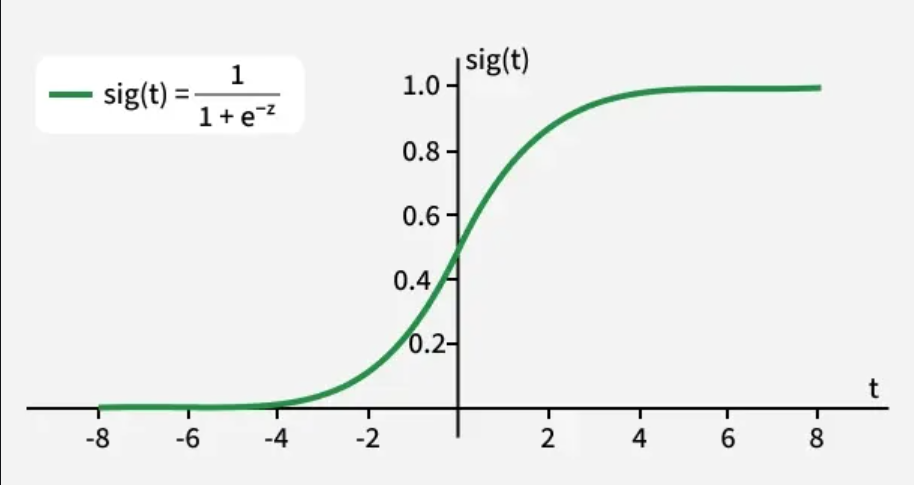

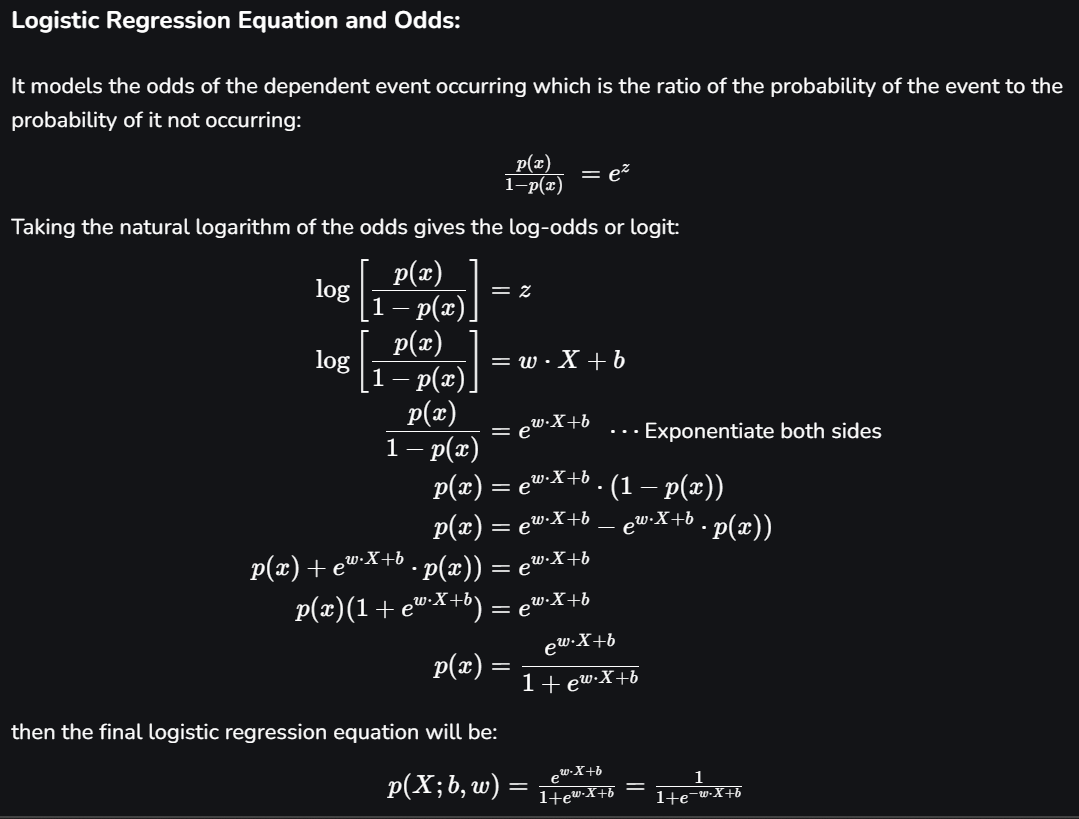

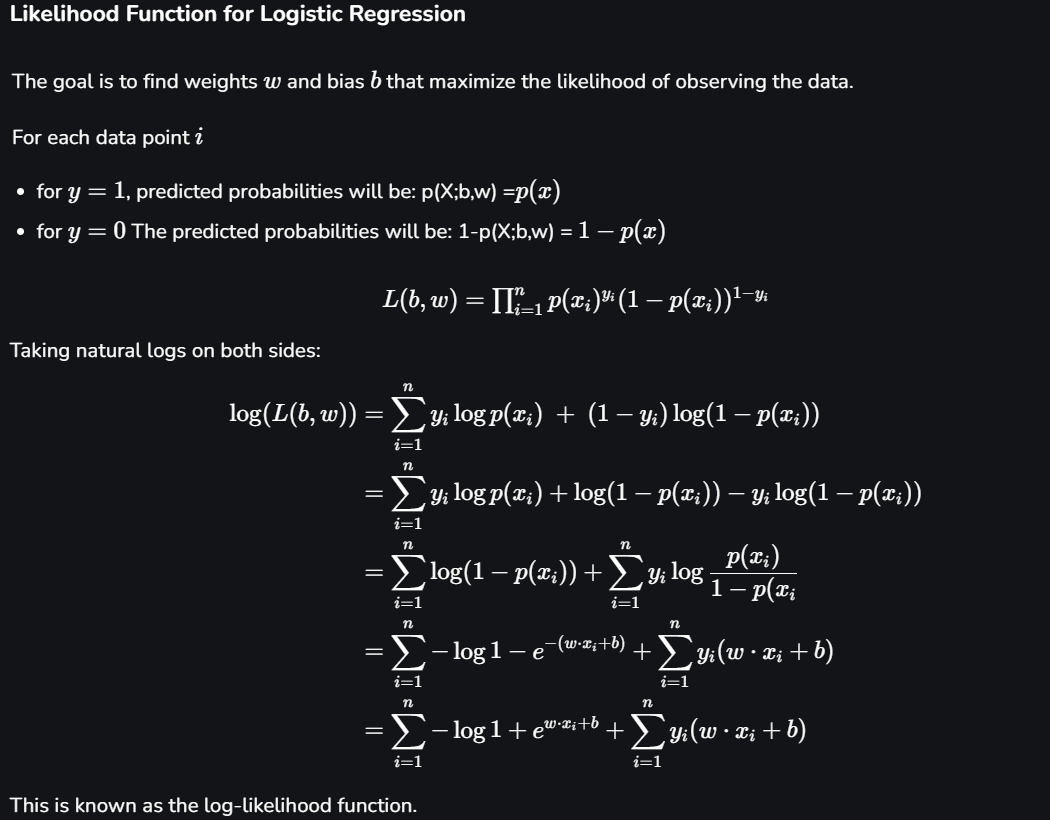

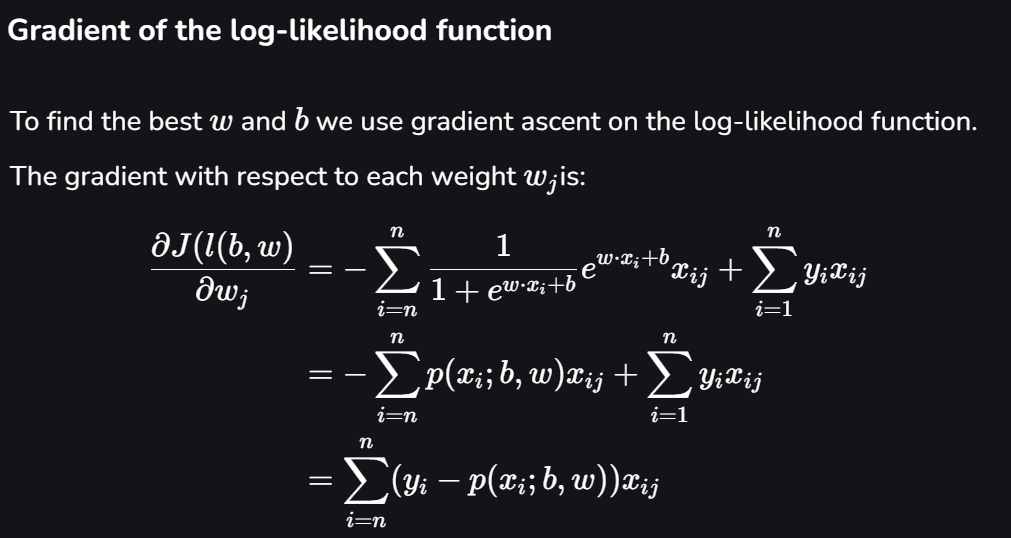

## ***TYPES OF LOGISTIC REGRESSION***

1. **Binomial Logistic Regression**:

   This type is used when the dependent variable has only two possible categories. Examples include Yes/No, Pass/Fail or 0/1. It is the most common form of logistic regression and is used for binary classification problems.


2. **Multinomial Logistic Regression**:
  
   This is used when the dependent variable has three or more possible categories that are not ordered. For example, classifying animals into categories like "cat," "dog" or "sheep." It extends the binary logistic regression to handle multiple classes.


3. **Ordinal Logistic Regression**:

   This type applies when the dependent variable has three or more categories with a natural order or ranking. Examples include ratings like "low," "medium" and "high." It takes the order of the categories into account when modeling.

## ***EVALUATION METRICES***

1. **ACCURACY:** Accuracy provides the proportion of correctly classified instances.
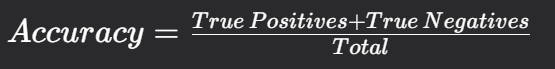

2.  **Precision**: Precision focuses on the accuracy of positive predictions.
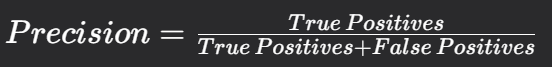

3. **Recall (Sensitivity or True Positive Rate)**: Recall measures the proportion of correctly predicted positive instances among all actual positive instances.


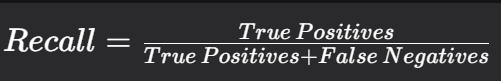

4.  **F1 Score:** F1 score is the harmonic mean of precision and recall.

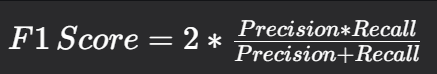

5. **Area Under the Receiver Operating Characteristic Curve (AUC-ROC):**

   The ROC curve plots the true positive rate against the false positive rate at various thresholds. AUC-ROC measures the area under this curve which provides an aggregate measure of a model's performance across different classification thresholds.

6.  **Area Under the Precision-Recall Curve (AUC-PR):**

    Similar to AUC-ROC, AUC-PR measures the area under the precision-recall curve helps in providing a summary of a model's performance across different precision-recall trade-offs.  

## ***CORE IDEA***

- This project builds a logistic regression-based model to predict the probability of stock price direction (up or down) in the next time step.

- Instead of forecasting exact returns, the model estimates the likelihood of positive returns using historical price-based features.

- These probabilities are then converted into simple trading signals (buy/sell/hold).

## ***WHY IT IS IMPORTANT***

This project teaches how to convert statistical predictions into actionable trading signals, which is a core quant skill. It highlights the gap between model accuracy and actual trading performance, which many beginners miss. You also learn about financial data challenges like noise and non-stationarity

In [80]:
from sklearn.externals._packaging.version import parse
# Import Neccessary Libararies
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, precision_recall_curve, auc, recall_score, precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Downloading Data
Asset = yf.download("^NSEI", start="2015-01-01", end="2026-04-01")
Asset = pd.DataFrame(Asset)
Asset.head()

/tmp/ipykernel_5059/1914154851.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Asset = yf.download("^NSEI", start="2015-01-01", end="2026-04-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [81]:
# Creating Returns Column
Asset['Returns'] = Asset['Close'].ffill().pct_change()
Asset

Price,Close,High,Low,Open,Volume,Returns
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,
Date,,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002031
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.029964
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003107
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016354
...,...,...,...,...,...,...
2026-03-23,22512.650391,22851.699219,22471.250000,22824.349609,550300,-0.026038
2026-03-24,22912.400391,23057.300781,22624.199219,22878.449219,538100,0.017757


In [82]:
Asset['ret_1'] = Asset['Returns']

Asset['volatility'] = Asset['Returns'].rolling(10).std()

In [83]:
Asset['ret_5'] = Asset['Close'].pct_change(5)
Asset['ma_10'] = Asset['Close'].rolling(10).mean()
Asset['ma_20'] = Asset['Close'].rolling(20).mean()

Asset['ma_diff'] = Asset['ma_10'] - Asset['ma_20']

In [88]:
# Creating Target Variable
Asset['future_return'] = Asset['Returns'].shift(-1)

Asset['target'] = (Asset['future_return'] > 0).astype(int)

Asset = Asset.dropna()

In [89]:
split = int(len(Asset) * 0.7)

train = Asset.iloc[:split]
test = Asset.iloc[split:]

In [90]:
features = ['ret_1', 'ret_5', 'ma_diff', 'volatility']

X_train = train[features].values
y_train = train['target'].values

X_test = test[features].values
y_test = test['target'].values

In [91]:
class LogisticRegressionCustom:

    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.beta = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            z = np.dot(X, self.beta)
            y_hat = self.sigmoid(z)

            gradient = np.dot(X.T, (y_hat - y)) / len(y)

            self.beta -= self.lr * gradient

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.beta))

In [92]:
# Train the model
model = LogisticRegressionCustom(lr=0.01, epochs=1000)
model.fit(X_train, y_train)

In [93]:
# Predict Probabilities
probs = model.predict_proba(X_test)

In [94]:
# Convert to Trading signals
signals = np.zeros_like(probs)

signals[probs > 0.55] = 1
signals[probs < 0.45] = -1

In [95]:
# Backtest Strategy
test_returns = test['future_return'].values

strategy_returns = signals * test_returns

In [96]:
# Evaluate Performance(ML Evaluation Metrices)
preds = (probs > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.49454545454545457


In [97]:
# Financial Performance Metrics
def sharpe(returns):
    return np.mean(returns) / np.std(returns) * np.sqrt(252)
print("Sharpe:", sharpe(strategy_returns))

Sharpe: 0.14067369496370954


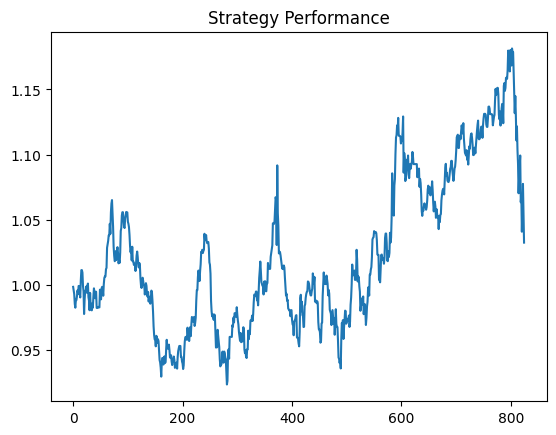

In [99]:
cum_returns = (1 + strategy_returns).cumprod()

plt.plot(cum_returns)
plt.title("Strategy Performance")
plt.show()